# CUPED - повышаем MDE (Controlled Experiments Using Pre Experiment Data)

<img src="./images/image.png" width="400"/>

Основная идея: найдем метрику до эксперимента $X$ (ковариату), которая скоррелирована с изначальной.

Тогда переходим от изначальной метрики $Y$

$$Y_{CUPED} = Y - \theta X$$
Где $\theta$ - какое-то число

> Важно: X и Y это некоторые метрики по каждому пользователю, в гипотезе мы будет сравнивать средние их значения в тестовой и контрольной группах

$$
\mathbb{V}\,\overline{Y}_{\text{cuped}}
=
\mathbb{V}\!\left(\overline{Y}-\theta\overline{X}\right)
=
\frac{\mathbb{V}(Y-\theta X)}{n}
=
\frac{\mathbb{V}Y-2\theta\,\operatorname{cov}(Y,X)+\theta^2\mathbb{V}X}{n}
$$

Минимальная дисперсия для $Y_{CUPED}$ будет в точке

$$
\theta_0=\frac{\operatorname{cov}(Y,X)}{\mathbb{V}X}
$$

Минимальная дисперсия равна:

$$
\min\!\left(\mathbb{V}\,\overline{Y}_{\text{cuped}}\right)
=
\mathbb{V}\,\overline{Y}\cdot(1-\rho^2),
\qquad
\text{где }
\rho=\frac{\operatorname{cov}(Y,X)}{\sqrt{\mathbb{V}Y\,\mathbb{V}X}}.
$$

То есть, чем больше корелляция $X$ и $Y$, тем лучше мы снижаем дисперсию

> Важно: мы считам $\theta$ уже после экперимента, при этом на Pooled выбоке. То есть не считаем отдельно для control and test (хотя так можно)

Если размеры групп достаточно велики, лучше оценивать $\theta$ на объединённых данных контрольной и экспериментальной групп. Если размеры групп малы, то оценка $\theta$ на исторических данных может дать лучшее качество.

**Идеи, какую можно брать ковариату. Самый простой способ - значение той же метрики на исторических данных**

<img src="./images/image copy.png" width="400"/>

> Если вы очень хотели увидеть эффект в эксперименте, но выбранный критерий показывает отсутствие значимых отличий, то, перебирая различные критерии и способы обработки данных, рано или поздно вы найдёте критерий, который покажет значимые отличия. Но такой подход увеличивает вероятности ошибок.

In [18]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [25]:
# Протестируем CUPED 
# Видим, что он более уверен (pvalue меньше)

# Делаем две коррелированные выборки из нормального распределения
def generate_data(sample_size, corr, mean=2000, sigma=300):
    means = np.array([mean, mean])
    cov = sigma ** 2 *np.array([[1, corr], [corr, 1]])
    data = stats.multivariate_normal(means, cov).rvs(sample_size).astype(int)
    df = pd.DataFrame({'metric': data[:, 0], 'covariate': data[:, 1]})
    return df

# Считаем theta
def calculate_theta(metric, covariate):

    theta = np.cov(metric, covariate)[0, 1] / np.var(covariate)

    return theta

# Обычный ttest
def ttest(control_df, test_df):
    pvalue = stats.ttest_ind(control_df['metric'], test_df['metric']).pvalue

    return pvalue

# CUPED ttest
def ttest_cuped(control_df, test_df, total_df):
    theta = calculate_theta(total_df['metric'], total_df['covariate'])

    control = control_df['metric'] - theta * control_df['covariate']
    test = test_df['metric'] - theta * test_df['covariate']

    pvalue = stats.ttest_ind(control, test).pvalue

    return pvalue

alpha = 0.05
beta = 0.2
sample_size=1000
corr = 0.7

mde = tt_solve_power(
    effect_size=None,  # This is what we want to find
    nobs=sample_size,         # sample size per group
    alpha=alpha,        # Type I error
    power=1-beta,         # 1 - beta (power)
    alternative='two-sided'
)

effect = max(20, mde)

# AB test

df_control = generate_data(sample_size, corr)
df_test = generate_data(sample_size, corr)
df_test['metric'] += effect
df_total = pd.concat([df_control, df_test])

pvalue = ttest(df_control, df_test)
pvalue_cuped = ttest_cuped(df_control, df_test, df_total)

print(f"Normal pvalue: {pvalue:.3f}")
print(f"CUPED pvalue: {pvalue_cuped:.3f}")

Normal pvalue: 0.140
CUPED pvalue: 0.081


100%|██████████| 3000/3000 [00:03<00:00, 805.77it/s]


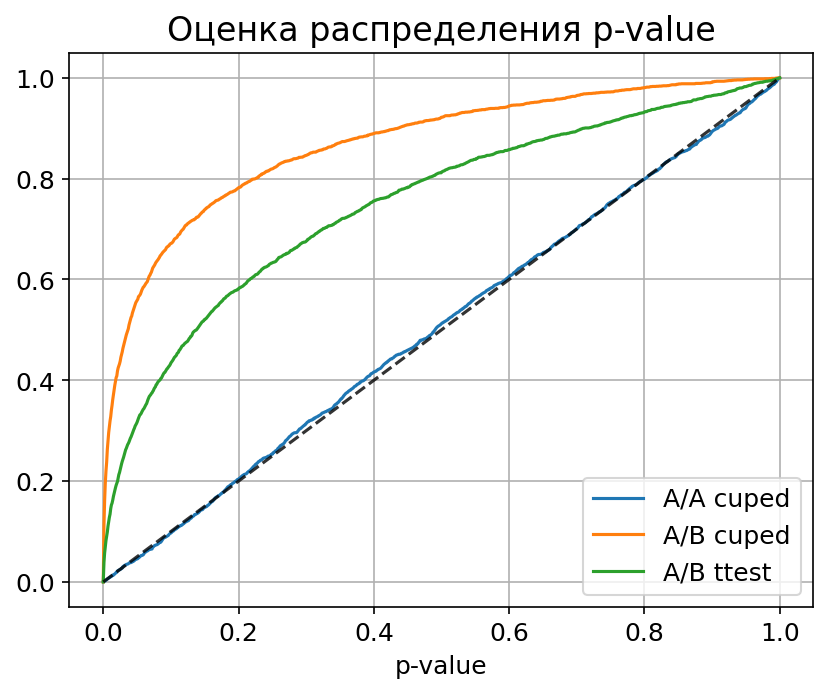

In [26]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

# Monte Carlo to estimate pvalues and check correctness
dict_pvalues = defaultdict(list)
n_iter = 3000
for _ in tqdm(range(n_iter)):
    df_control = generate_data(sample_size, corr)
    df_test = generate_data(sample_size, corr)
    df_total = pd.concat([df_control, df_test])

    dict_pvalues['A/A cuped'].append(ttest_cuped(df_control, df_test, df_total))
    df_test['metric'] += effect
    df_total = pd.concat([df_control, df_test])
    dict_pvalues['A/B cuped'].append(ttest_cuped(df_control, df_test, df_total))
    dict_pvalues['A/B ttest'].append(ttest(df_control, df_test))

plot_pvalue_distribution(dict_pvalues)

### Bivariate Bernoulli Probabilities for Binary Metrics

Given a shared mean $\mu$ and a target correlation $\rho$, the joint probabilities $p_1$ through $p_4$ are calculated as follows:

Given: $P(X=1) = \mu$   
$P(Y=1) = \mu$, and      
$Correlation = \rho$

#### 1. Probability both are 1 ($p_4$)
From the definition of correlation $\rho = \frac{E(XY) - E(X)E(Y)}{\sigma_X \sigma_Y} = \frac{p_4 - \mu^2}{\mu(1-\mu)}$:
$$p_4 = P(X=1, Y=1) = \rho \mu (1-\mu) + \mu^2$$

> Note: we use that E(XY) = p4, because XY=1 only when X = 1 and Y = 1

#### 2. Probabilities for mixed cases ($p_2$ and $p_3$)
Because the marginal probability $P(X=1) = p_3 + p_4 = \mu$ and $P(Y=1) = p_2 + p_4 = \mu$:
$$p_2 = P(X=0, Y=1) = \mu - p_4$$
$$p_3 = P(X=1, Y=0) = \mu - p_4$$

#### 3. Probability both are 0 ($p_1$)
$$p_1 = P(X=0, Y=0) = 1 - p_2 - p_3 - p_4 =  \rho \mu (1-\mu) + (1-\mu)^2$$

### Summary Table


| Outcome $(X, Y)$ | Variable | Formula |
| :--- | :--- | :--- |
| **(0, 0)** | $p_1$ | $\rho \mu (1-\mu) + (1-\mu)^2$ |
| **(0, 1)** | $p_2$ | $\mu - p_4$ |
| **(1, 0)** | $p_3$ | $\mu - p_4$ |
| **(1, 1)** | $p_4$ | $\rho \mu (1-\mu) + \mu^2$ |


100%|██████████| 10000/10000 [00:12<00:00, 786.36it/s]


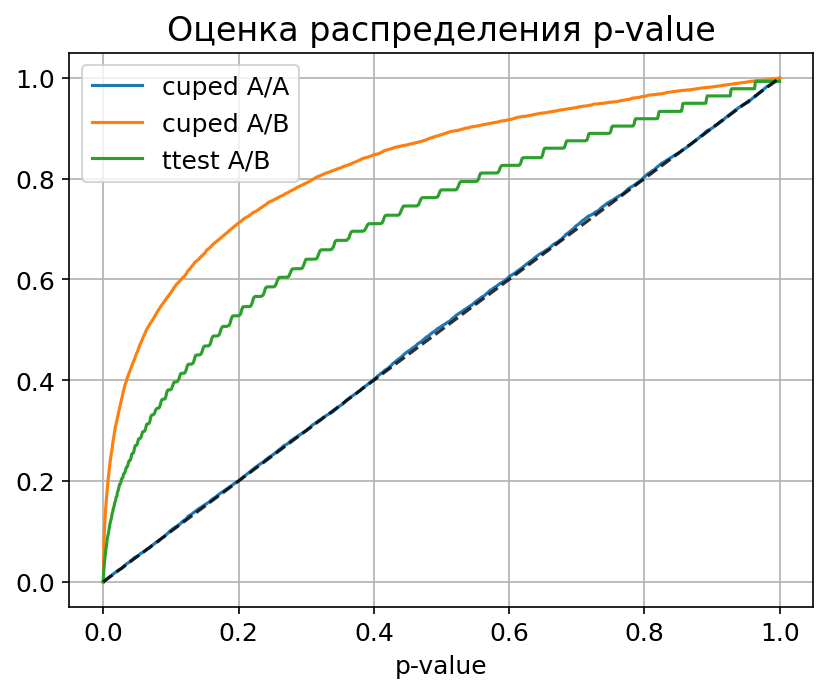

In [ ]:
# Теперь можно посмотреть, что CUPED работает на бинарных метриках 
# Видим, что и здесь он корректен для А/А теста (прямая равномерна от 0 до 1)
# Для AB теста его мощность выше, чем ttest

# Генерируем коррелированные бинарные данные исходной метрики и ковариаты.
# x_i \sim Ber(sample_size, mean)
def generate_bin_data(sample_size, corr, mean):
    p1 = corr * mean * (1 - mean) + (1 - mean) ** 2
    p2 = p3 = 1 - mean - p1
    p4 = p1 + 2 * mean - 1
    variants = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    samples = np.random.choice([0, 1, 2, 3], size=sample_size, replace=True, p=[p1, p2, p3, p4])
    res = variants[samples]
    df = pd.DataFrame(res, columns=['metric', 'covariate'])
    return df

sample_size = 1000
corr = 0.7
mean = 0.4
effect = 0.03
dict_pvalues = defaultdict(list)

for _ in tqdm(range(10000)):
    df_control = generate_bin_data(sample_size, corr, mean)
    df_test = generate_bin_data(sample_size, corr, mean)
    df_theta = pd.concat([df_control, df_test])
    dict_pvalues['cuped A/A'].append(ttest_cuped(df_control, df_test, df_theta))
    zero_mask = df_test['metric'] == 0
    # New Mean = good / N + bad * p / N (we change some bad to good with probabiltiy p)
    # (replace good and bad with current mean)
    # New Mean = mean + p * (1 - mean)
    # (we want New Mean = mean + effect)
    # mean + effect = mean + p * (1 - mean)
    # p = effect / (1 - mean)
    p = effect / (1 - mean)
    effect_mask = stats.binom(1, p).rvs(sample_size)
    df_test.loc[zero_mask & effect_mask, 'metric'] = 1
    df_theta = pd.concat([df_control, df_test])
    dict_pvalues['cuped A/B'].append(ttest_cuped(df_control, df_test, df_theta))
    dict_pvalues['ttest A/B'].append(ttest(df_control, df_test))

plot_pvalue_distribution(dict_pvalues)

    

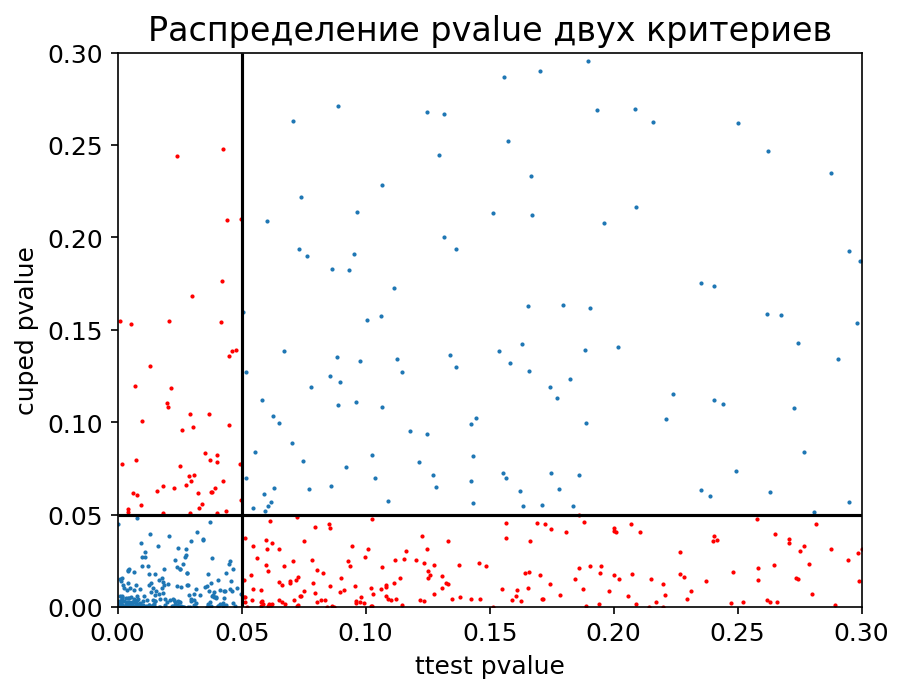

In [ ]:
# Если один критерий более мощный, это не значит, 
# что он будет выдавать всегда правильный ответ
# CUPED может давать неправильный ответ, а ttest правильный 

# Делам AB тест

sample_size = 1000
corr = 0.7
effect = 20
dict_pvalues = defaultdict(list)

for _ in range(1000):
    df_control = generate_data(sample_size, corr)
    df_test = generate_data(sample_size, corr)
    df_test['metric'] += effect
    df_theta_ab = pd.concat([df_control, df_test])
    dict_pvalues['cuped'].append(ttest_cuped(df_control, df_test, df_theta_ab))
    dict_pvalues['ttest'].append(ttest(df_control, df_test))

df = pd.DataFrame(dict_pvalues)
df['res_cuped'] = df['cuped'] < 0.05
df['res_ttest'] = df['ttest'] < 0.05
df_eq = df[df['res_cuped'] == df['res_ttest']]
df_neq = df[df['res_cuped'] != df['res_ttest']]

plt.plot(df_eq['ttest'], df_eq['cuped'], 'o', markersize=1)
plt.plot(df_neq['ttest'], df_neq['cuped'], 'ro', markersize=1)
plt.hlines(0.05, 0, 0.3, colors='k')
plt.vlines(0.05, 0, 0.3, colors='k')
plt.xlim(0, 0.3)
plt.ylim(0, 0.3)
plt.xlabel('ttest pvalue', size=12)
plt.ylabel('cuped pvalue', size=12)
plt.title('Распределение pvalue двух критериев', size=16)
plt.show()

Что на графике

| ttest прав, cuped неправ   | ttest неправ, cuped неправ |
|---------------|--------------|
| **ttest прав, cuped прав**   | **ttest неправ, cuped прав**      |